# Introduction 
In this project we will explore the dataset of job listing in data science in australia. As an international student in Sydney pursuing a Masters in Applied AI, I used this dataset to understand the Australian data science job market and guide my own career decisions.

Here we will try to analyse and answer the below questions
- Which skills are most in demand in Australia?
- Which cities have the most data science jobs?
- What's the average salary range?
- Which industries hire the most data scientists?

In [2]:
import pandas as pd
import numpy as np

## Load the Data

In [61]:
df = pd.read_csv('archive-3/AustraliaDataScienceJob2.csv')
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(652, 53)
Job Title                          0
Job Location                       0
Company                            0
Url                                0
Estimate Base Salary               0
Low Estimate                       0
High Estimate                      0
Company Size                      90
Company Type                      90
Company Sector                   173
Company Founded                  281
Company Industry                 173
Company Revenue                   90
Job Descriptions                   1
Company Rating                   115
Company Friend Reccomendation    159
Company CEO Approval             227
Companny Number of Rater         537
Company Career Opportinities     152
Compensation and Benefits        152
Company Culture and Values       152
Company Senior Management        152
Company Work Life Balance        152
Country                            0
State                              0
python_yn                          0
r_yn                        

## Analysis and Plotting

### Skillset in Demand

sql           126
python        125
mathematic     89
excel          84
java           76
aws            70
git            57
statistic      44
javascript     41
r              40
dtype: int64


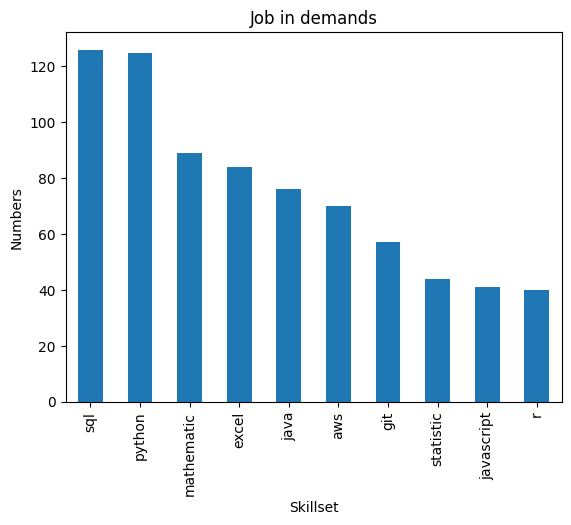

In [75]:
skill_demands= df.filter(regex='_yn$').sum(axis=0)
skill_demands_sorted= skill_demands.sort_values(ascending=False).head(10)
skill_demands_sorted.index = skill_demands_sorted.index.str.replace('_yn','')
axe = skill_demands_sorted.plot.bar(rot= 90)
axe.set_title('Job in demands')
axe.set_xlabel('Skillset')
axe.set_ylabel('Numbers')
print(skill_demands_sorted.head(10))

### State with High Jobs

State
Victoria              302
Queensland            121
Western Australia      66
New South Wales        58
South Australia        57
Tasmania               26
Northern Territory     22
Name: Job Title, dtype: int64


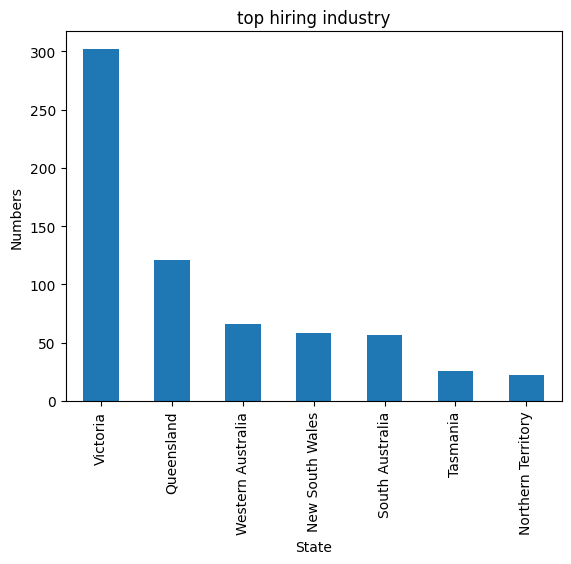

In [40]:
most_jobs = df.groupby('State')['Job Title'].count()
most_jobs_sorted = most_jobs.sort_values(ascending = False)
axe = most_jobs_sorted.plot.bar(rot= 90)
axe.set_title('State with Most Jobs')
axe.set_xlabel('State')
axe.set_ylabel('Numbers')
print(most_jobs_sorted)

### Average salary for each state 

State
Tasmania              113836.0
New South Wales       105776.0
Victoria              105445.0
Northern Territory    103242.0
Western Australia     102843.0
South Australia       101747.0
Queensland            100215.0
Name: Estimate Base Salary, dtype: float64


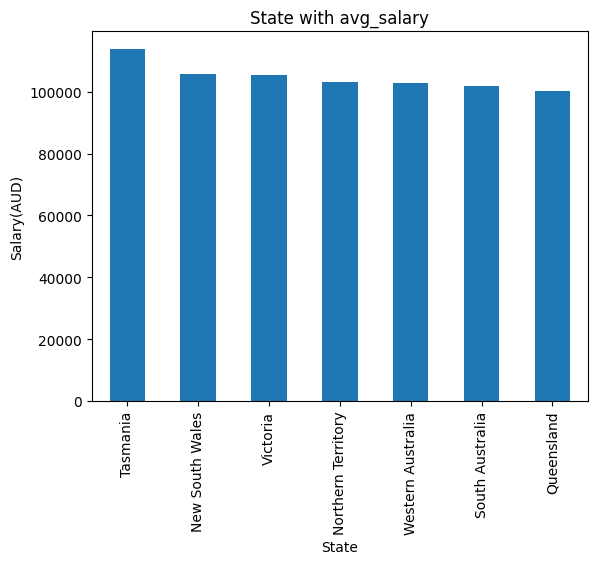

In [77]:
avg_salary = df.groupby('State')['Estimate Base Salary'].mean()
avg_salary_sorted = round(avg_salary.sort_values(ascending = False))
axe = avg_salary_sorted.plot.bar(rot= 90)
axe.set_title('State with avg_salary')
axe.set_xlabel('State')
axe.set_ylabel('Salary(AUD)')
print(avg_salary_sorted)

### Industry which needs more Data Scientist

Company Industry
Banking & Lending                          90
National Services & Agencies               83
Biotech & Pharmaceuticals                  68
Architectural & Engineering Services       25
Colleges & Universities                    24
Information Technology Support Services    18
Business Consulting                        15
Broadcast Media                            13
Computer Hardware Development              13
HR Consulting                              11
Name: Job Title, dtype: int64


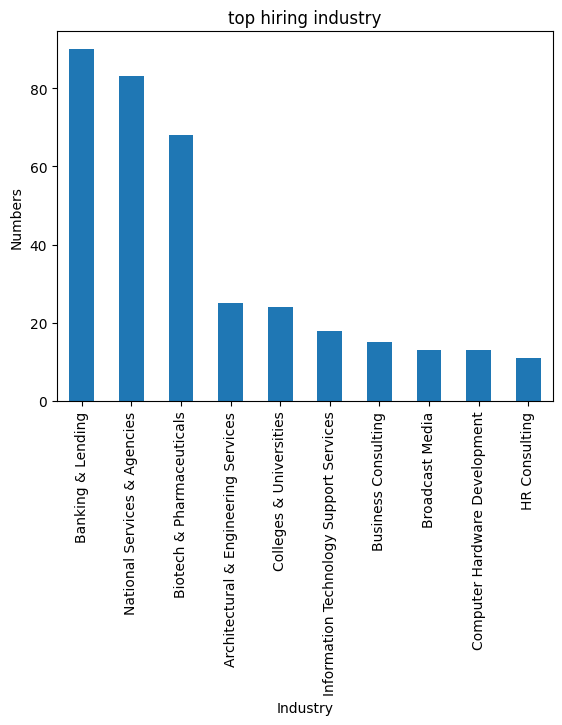

In [81]:
most_hiring = df.groupby('Company Industry')['Job Title'].count()
most_hiring_sorted = (most_hiring.sort_values(ascending = False)).head(10)
axe = most_hiring_sorted.plot.bar(rot= 90)
axe.set_title('top hiring industry')
axe.set_xlabel('Industry')
axe.set_ylabel('Numbers')
print(most_hiring_sorted.head(10))

### Insights 
- We can see there is a huge demand for Python and SQL skillsets when compared with others. The people in Victoria can have plenty of opportunities compared with other states. SQL (126 jobs) and Python (125 jobs) are almost equal in demand, together appearing in nearly 40% of all job postings. Excel and Mathematics follow, suggesting employers value both technical and analytical skills.
- Victoria has 302 jobs, more than double Queensland's 121, making Melbourne the clear hub for data science roles in Australia.
- Despite being the least opportunity-providing state in the market, Tasmania holds the highest average salary when compared with other states. Tasmania averages 113,836 AUD but with only 26 jobs. NSW and Victoria offer $105k+ with far more opportunities better risk for job seekers.
- The banking and lending industry requires more data scientists, followed by national services , as banking deals with money; it needs more analysis of customer behavior or spending habits. Banking & Lending leads with 90 jobs, suggesting financial institutions are the largest employers of data professionals in Australia.

- As an international student based in Sydney, this analysis reveals that expanding the job search to Victoria or targeting banking sector roles could significantly increase employment opportunities, given NSW has only 58 postings compared to Victoria's 302.